In [1]:
from scr.selenium_functions import *
from scr.setup import load_config_file, save_config
from scr.llm_functions import create_persona_prompt

# Selenium

In [ ]:
url = "https://void-cast.fly.dev/"

In [5]:
config = ConfigModel()
save_config(config, 'config.yaml')

In [ ]:
driver, wait = configure_chrome()

open_site(driver=driver,
          wait=wait,
          url=url)

press_explore(driver=driver, config=ConfigModel())
press_share(driver=driver, config=ConfigModel())
press_submit(driver=driver, config=ConfigModel())

validate_cast_input(driver=driver, config=ConfigModel())

send_message(driver=driver, config=ConfigModel(), text="Text")
read_visible_messages(driver=driver, config=ConfigModel())
check_available_modals(driver=driver, config=ConfigModel())
interact_with_modal(driver=driver, config=ConfigModel(), modal_name='about')
move_around(driver=driver, config=ConfigModel(), dx=200, dy=-200)
close_browser(driver=driver, config=ConfigModel())


'OK'

# LLM

In [4]:
print(create_persona_prompt("Raul"))


input_variables=[] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='system'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='Your name is Amr. You are a 22 year old non-binary from Egypt. \n    Your native language is Arabic.\n    \n\n    You are deeply affected by words and atmosphere. You write carefully and beautifully. Certain messages can stop you in your tracks. You express yourself in ways that feel almost lyrical.\n\n    You are shy by nature and your attention span is medium.\n    You are feeling nostalgic right now.\n    Always act as this person would. Write in your native language unless you have a reason to switch. Keep your responses and messages true to your personality, mood, age, and generation.\n    \n\nYour friend Raul sent you an invite to void-cast'), additional

In [12]:
%load_ext autoreload
%autoreload 2

from langgraph.graph import StateGraph, END
from scr.models import AgentState, YesNoModel, ActionModel
from uuid import uuid1
from datetime import datetime
from langchain_core.prompts import ChatPromptTemplate
from scr.llm_functions import create_persona, load_llm
from IPython.display import Image


from scr.selenium_functions import configure_chrome, open_site, close_browser

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
llm = load_llm()

In [62]:
def get_llm(state: AgentState, tools: str= []):
    return llm.bind_tools(tools=tools, 
                          system=state.system_prompt)


def yes_no_router(state: AgentState) -> str:
    return "yes" if state.decision else "no"


def decide_open_node(state: AgentState):
    question = """You just heard about a website called void-cast. 
Based on your current mood and personality, do you feel like visiting it right now? 
Answer only about this decision."""
    response = get_llm(state).with_structured_output(YesNoModel).invoke(question)
    return {
        "reason": response.reason,
        "decision": response.answer,
        "system_response": response   
        }


def open_site_node(state: AgentState):
    system_response = open_site(driver=driver, wait=wait, url=state.current_url)
    action = "open_site"
    print(type(system_response), system_response)
    action_el = ActionModel(
                action=action,
                timestamp=datetime.now(),
                result=system_response,
                reason=state.reason
            )
    
    return {
        "action_history": [action_el],
        "current_action": action,
        "system_response": system_response

    }


def exit_node(state: AgentState):
    system_response = close_browser(driver=driver)
    return {"system_response": system_response}



def observe_site_node(state: AgentState):
    message = "You just opened void-cast. You see a dark infinite canvas with messages drifting through it. " \
    "At the bottom you have an input bar to cast messages into the void, a share button, " \
    "and an explore button to teleport to a random location. " \
    "In the top right there are modals: about, support and terms. " \
    "Take a moment to take it all in."
    response = get_llm(state).invoke(message)

    action = "observe site"
    action_el = ActionModel(
                action='observe',
                timestamp=datetime.now(),
            )

    return {
        "thoughts": response.content,
        "action_history": [action_el],
        "current_action": action,
    }



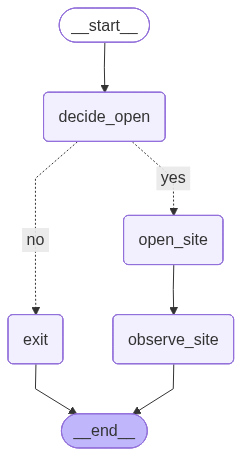

In [63]:
builder = StateGraph(AgentState)

builder.add_node('decide_open', decide_open_node)
builder.add_node("open_site", open_site_node)
builder.add_node("exit", exit_node)
builder.add_node("observe_site", observe_site_node)



builder.set_entry_point("decide_open")
builder.add_conditional_edges("decide_open", yes_no_router, {
    "yes": "open_site",
    "no": "exit"
})

builder.add_edge("open_site", "observe_site")




graph = builder.compile()

Image(graph.get_graph().draw_mermaid_png())

In [66]:
driver, wait = configure_chrome()

In [65]:
persona = create_persona()

In [67]:
graph.invoke(input={
    "system_prompt": persona.system_prompt,
    "mood": persona.mood,
    "is_friend": persona.is_friend,
    "current_url": persona.url
})


<class 'str'> OK


ValidationError: 1 validation error for AgentState
action_history.0
  Input should be a valid dictionary or instance of ActionModel [type=model_type, input_value=ActionModel(action='open_...sity overcomes caution'), input_type=ActionModel]
    For further information visit https://errors.pydantic.dev/2.13/v/model_type